# 09 — Regex-Redux Deep Dive

**Winner: Rust** (~23 J) — essentially tied with Haskell (~24 J, 1.05×). C is 3rd (~28.7 J).

Notable patterns:
- **Rust and Haskell are statistically indistinguishable** on this benchmark — both leverage highly optimised regex engines (`regex` crate for Rust; `pcre`/`regex-tdfa` for Haskell).
- **Go is worst among compiled/JIT languages** (~504 J, 21.9×) — Go's standard `regexp` package uses a Thompson NFA engine that is correct but slower than PCRE-backed engines used by other languages.
- **Java is 2nd-worst among compiled languages** (~298 J) — the `java.util.regex` engine adds overhead.
- **PHP (~40 J, 4th overall)** performs surprisingly well — it uses PCRE2 natively under the hood.
- **Lua (~56 J)** also overperforms its usual position, for the same PCRE-binding reason.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BENCHMARK = 'regex-redux'
RUNS_CSV  = Path('../results/results_clean_runs.csv')
MEAN_CSV  = Path('../results/results_clean.csv')
FIGS_DIR  = Path('../results/figs/regex_redux')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

def save(name): plt.savefig(FIGS_DIR / f'{name}.pdf', bbox_inches='tight'); plt.show()
def find_col(df, kw): return next(c for c in df.columns if kw in c)
unit = lambda col: col.rsplit('-', 1)[-1].upper()

---
## 1. Load data

In [2]:
bt_runs  = pd.read_csv(RUNS_CSV)
bt_runs  = bt_runs[bt_runs['benchmark'] == BENCHMARK].copy()
bt_means = pd.read_csv(MEAN_CSV)
bt_means = bt_means[bt_means['benchmark'] == BENCHMARK].set_index('language')

COL_CPU_E  = find_col(bt_runs, 'cpu_energy')
COL_MEM_E  = find_col(bt_runs, 'memory_energy')
COL_CARBON = find_col(bt_runs, 'cpu_carbon')
COL_TIME   = find_col(bt_runs, 'phase_time')

print(f'Per-run rows: {len(bt_runs)} | Mean rows: {len(bt_means)}')
bt_means[[COL_CPU_E, COL_TIME]].sort_values(COL_CPU_E).round(3)

Per-run rows: 148 | Mean rows: 18


,cpu_energy_rapl_msr_component-package_0-j,phase_time_syscall_system-system-s
language,,
rust,23.018,1.696
haskell,23.966,1.336
c,28.591,1.149
cpp,30.116,1.376
php,39.806,2.015
ocaml,41.733,2.202
fsharp,44.791,1.952
lua,56.026,3.905
nodejs,60.995,3.896


---
## 2. Strip plot — per-run consistency

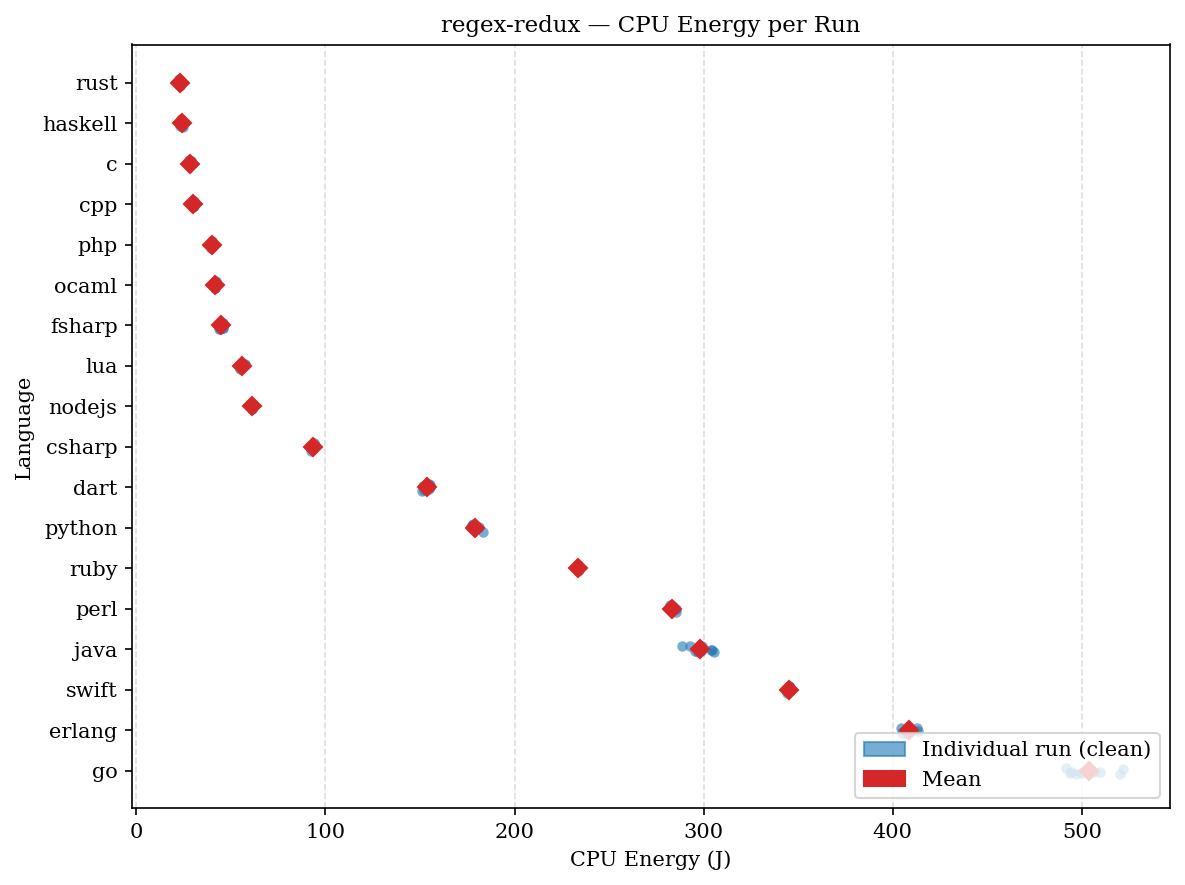

In [3]:
order = bt_means[COL_CPU_E].sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=bt_runs, x=COL_CPU_E, y='language', order=order,
              jitter=True, alpha=0.6, size=5, color='#1f77b4', ax=ax)
for i, lang in enumerate(order):
    ax.plot(bt_means.loc[lang, COL_CPU_E], i, marker='D', color='#d62728', markersize=6, zorder=5)

ax.legend(handles=[
    mpatches.Patch(color='#1f77b4', alpha=0.6, label='Individual run (clean)'),
    mpatches.Patch(color='#d62728', label='Mean'),
], loc='lower right')
ax.set_xlabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_ylabel('Language')
ax.set_title(f'{BENCHMARK} — CPU Energy per Run')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('stripplot_cpu_energy')

---
## 3. Ranked bar — highlighting Go and Java anomalies

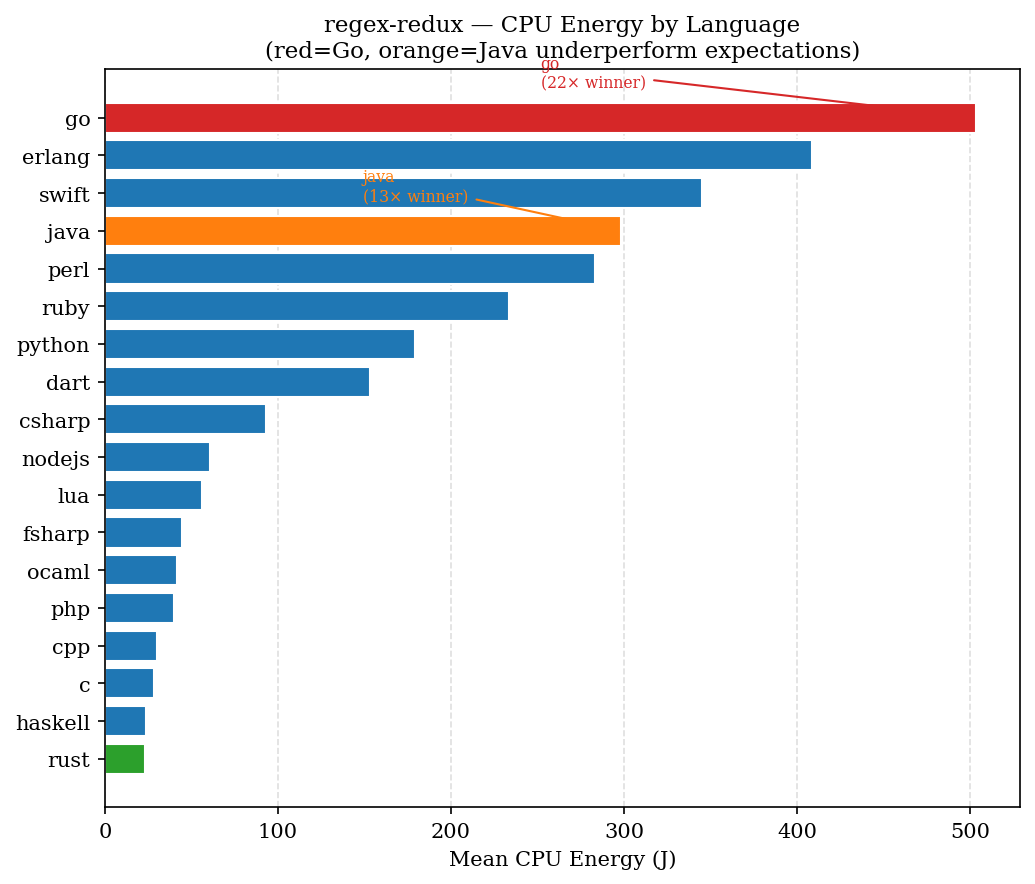

In [4]:
means = bt_means.sort_values(COL_CPU_E)
winner = means.index[0]
ANOMALIES = {'go': '#d62728', 'java': '#ff7f0e'}  # languages that underperform expectations

colors = []
for i, lang in enumerate(means.index):
    if i == 0:
        colors.append('#2ca02c')
    elif lang in ANOMALIES:
        colors.append(ANOMALIES[lang])
    else:
        colors.append('#1f77b4')

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(means.index, means[COL_CPU_E], color=colors, edgecolor='white')

for lang, color in ANOMALIES.items():
    pos = means.index.tolist().index(lang)
    ax.annotate(f'{lang}\n({means.loc[lang,COL_CPU_E]/means.loc[winner,COL_CPU_E]:.0f}× winner)',
        xy=(means.loc[lang, COL_CPU_E], pos),
        xytext=(means.loc[lang, COL_CPU_E] * 0.5, pos + 0.8),
        fontsize=7.5, color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.0),
    )

ax.set_xlabel(f'Mean CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — CPU Energy by Language\n(red=Go, orange=Java underperform expectations)')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
save('bar_cpu_energy')

---
## 4. Normalised to winner

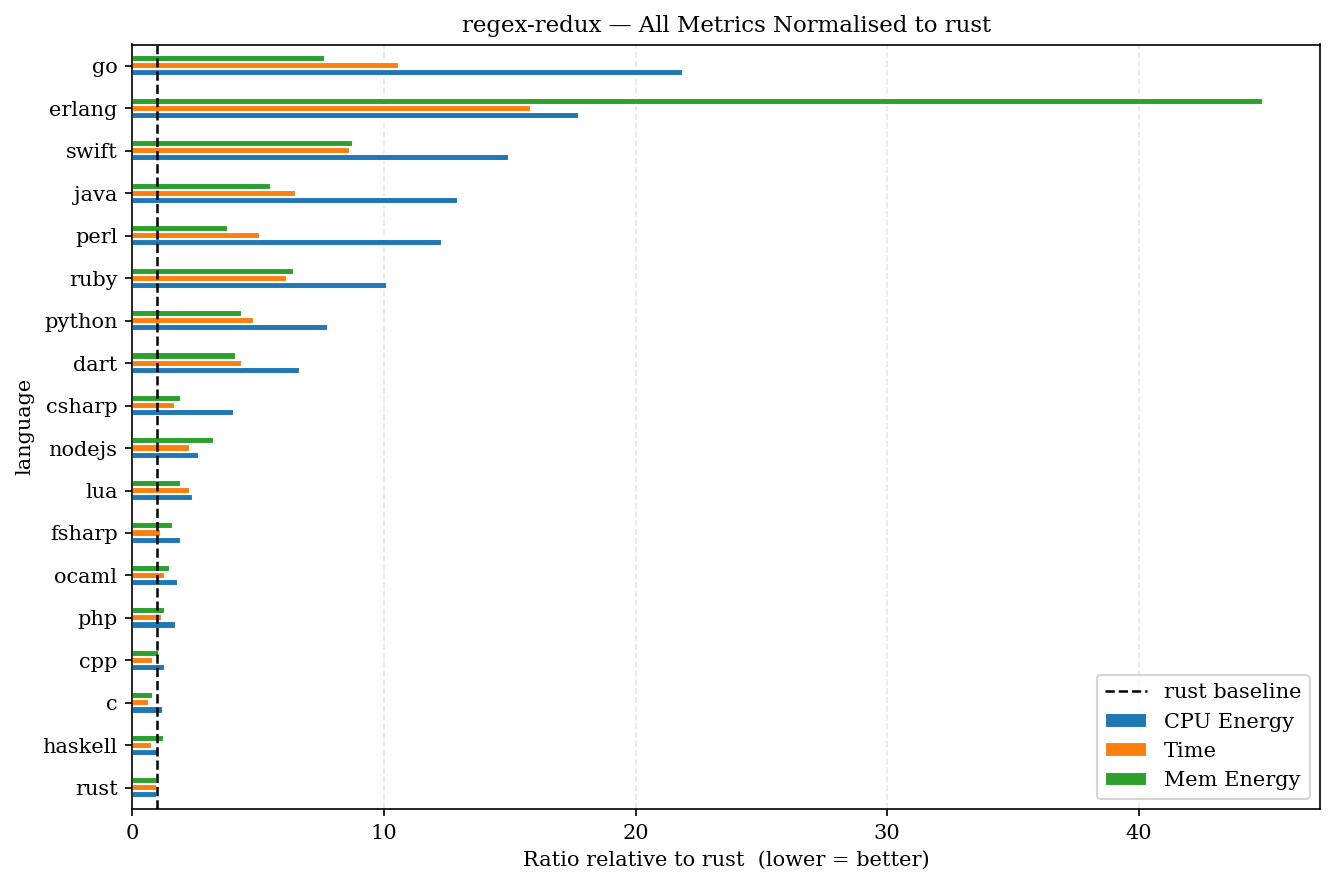

In [5]:
subset = means[[COL_CPU_E, COL_TIME, COL_MEM_E]]
ratio = subset.div(subset.loc[winner])
ratio.columns = ['CPU Energy', 'Time', 'Mem Energy']

fig, ax = plt.subplots(figsize=(9, 6))
ratio.plot(kind='barh', ax=ax, edgecolor='white')
ax.axvline(1.0, color='black', linewidth=1.2, linestyle='--', label=f'{winner} baseline')
ax.set_xlabel(f'Ratio relative to {winner}  (lower = better)')
ax.set_title(f'{BENCHMARK} — All Metrics Normalised to {winner}')
ax.legend(loc='lower right')
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
save('normalised')

---
## 5. Energy vs. Time scatter

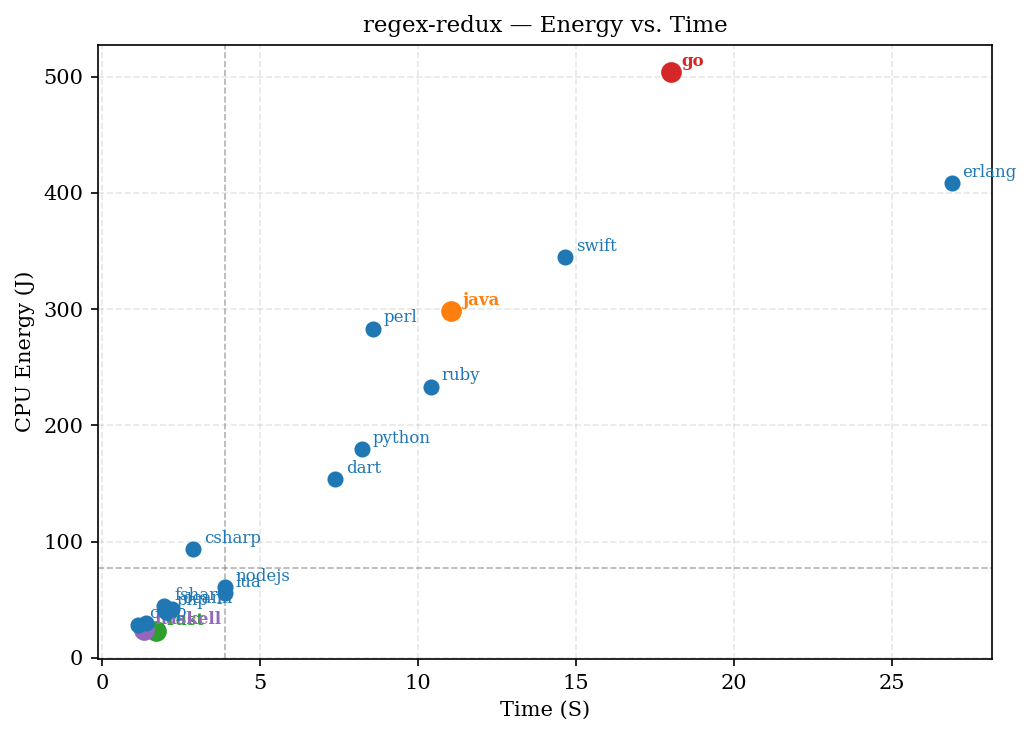

In [6]:
HIGHLIGHT = {'rust': '#2ca02c', 'haskell': '#9467bd', 'go': '#d62728', 'java': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(7, 5))
for lang, row in means.iterrows():
    color = HIGHLIGHT.get(lang, '#1f77b4')
    ax.scatter(row[COL_TIME], row[COL_CPU_E], color=color, s=80 if lang in HIGHLIGHT else 45, zorder=3)
    ax.annotate(lang, (row[COL_TIME], row[COL_CPU_E]),
                textcoords='offset points', xytext=(5, 3), fontsize=8,
                color=color, fontweight='bold' if lang in HIGHLIGHT else 'normal')

ax.axvline(means[COL_TIME].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(means[COL_CPU_E].median(), color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel(f'Time ({unit(COL_TIME)})')
ax.set_ylabel(f'CPU Energy ({unit(COL_CPU_E)})')
ax.set_title(f'{BENCHMARK} — Energy vs. Time')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
save('scatter_energy_vs_time')

---
## 6. Summary table

In [7]:
summary = means[[COL_CPU_E, COL_TIME, COL_MEM_E, COL_CARBON]].copy()
summary.columns = [f'CPU Energy ({unit(COL_CPU_E)})', f'Time ({unit(COL_TIME)})',
                   f'Mem Energy ({unit(COL_MEM_E)})', f'CPU Carbon ({unit(COL_CARBON)})']
summary.round(4)

,CPU Energy (J),Time (S),Mem Energy (J),CPU Carbon (G)
language,,,,
rust,23.0180,1.6958,0.7784,0.0021
haskell,23.9658,1.3358,0.9787,0.0022
c,28.5906,1.1491,0.6369,0.0027
cpp,30.1164,1.3764,0.8197,0.0028
php,39.8062,2.0155,1.0054,0.0037
ocaml,41.7326,2.2015,1.1801,0.0039
fsharp,44.7909,1.9525,1.2715,0.0042
lua,56.0261,3.9053,1.5134,0.0052
nodejs,60.9946,3.8955,2.5427,0.0057
